# fio rand_write — 3-engine comparison: dfs / dfuse / dfuse+libioil

**Platform:** Aurora (HPE Cray EX), DAOS pool `e2sar`  
**Pattern:** random write (`randwrite`)  
**Config:** bs=1m, numjobs=16, iodepth=16, runtime=60 s, group_reporting  
**Engines:**
- `dfs` — DAOS native userspace ioengine (direct DAOS API)
- `dfuse` — kernel `libaio` via DFuse POSIX mount (no intercept)
- `libil` — kernel `libaio` via DFuse + `LD_PRELOAD libioil.so` (DAOS intercept lib)

The `libil` JSON will be picked up automatically once dropped into this directory.  
> **Observed:** `libioil` bandwidth is *lower* than plain DFuse — see Key Findings §5 for explanation.

In [1]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

RESULTS_DIR = Path(".")

ENGINE_ORDER  = ["dfs", "dfuse", "libil"]
ENGINE_LABELS = {
    "dfs":   "DFS (native)",
    "dfuse": "DFuse (libaio)",
    "libil": "DFuse+libioil",
}
COLORS = {
    "dfs":   "#1f77b4",
    "dfuse": "#ff7f0e",
    "libil": "#2ca02c",
}

In [2]:
def engine_from_stem(stem: str) -> str:
    """Extract engine tag (dfs / dfuse / libil) from filename stem."""
    for tag in ENGINE_ORDER:
        if f"_{tag}_" in stem or stem.startswith(f"fio_{tag}_"):
            return tag
    return stem  # fallback


def parse_file(fpath: Path) -> dict:
    engine = engine_from_stem(fpath.stem)
    with open(fpath) as f:
        d = json.load(f)
    j = d["jobs"][0]
    w = j["write"]
    pct = w["clat_ns"]["percentile"]
    opts = j["job options"]
    return dict(
        engine        = engine,
        label         = ENGINE_LABELS.get(engine, engine),
        ioengine      = opts.get("ioengine", "?"),
        bs            = opts.get("bs", "?"),
        numjobs       = int(opts.get("numjobs", 0)),
        iodepth       = int(opts.get("iodepth", 0)),
        bw_GBs        = w["bw_bytes"] / 1e9,
        iops          = w["iops"],
        lat_mean_ms   = w["lat_ns"]["mean"]  / 1e6,
        clat_mean_ms  = w["clat_ns"]["mean"] / 1e6,
        slat_mean_us  = w["slat_ns"]["mean"] / 1e3,
        clat_p50_ms   = pct["50.000000"]     / 1e6,
        clat_p90_ms   = pct["90.000000"]     / 1e6,
        clat_p95_ms   = pct["95.000000"]     / 1e6,
        clat_p99_ms   = pct["99.000000"]     / 1e6,
        clat_p999_ms  = pct["99.900000"]     / 1e6,
        clat_p9999_ms = pct["99.990000"]     / 1e6,
        usr_cpu       = j["usr_cpu"],
        sys_cpu       = j["sys_cpu"],
    )


rows = [parse_file(f) for f in sorted(RESULTS_DIR.glob("fio_*.json"))]
df = pd.DataFrame(rows)
df["engine"] = pd.Categorical(df["engine"], categories=ENGINE_ORDER, ordered=True)
df = df.sort_values("engine").reset_index(drop=True)
df

,engine,label,ioengine,bs,numjobs,iodepth,bw_GBs,iops,lat_mean_ms,clat_mean_ms,slat_mean_us,clat_p50_ms,clat_p90_ms,clat_p95_ms,clat_p99_ms,clat_p999_ms,clat_p9999_ms,usr_cpu,sys_cpu
0,dfs,DFS (native),dfs,1m,16,16,96.074066,91623.368832,2.652201,2.637467,14.734372,2.473984,3.522560,4.046848,5.537792,12.910592,51.118080,95.379750,1.654978
1,dfuse,DFuse (libaio),libaio,1m,16,16,15.753665,15023.865871,16.753990,15.968224,785.765962,15.925248,17.432576,17.956864,19.267584,20.578304,21.889024,25.884283,1.279563


## Bandwidth, IOPS, and Mean Latency

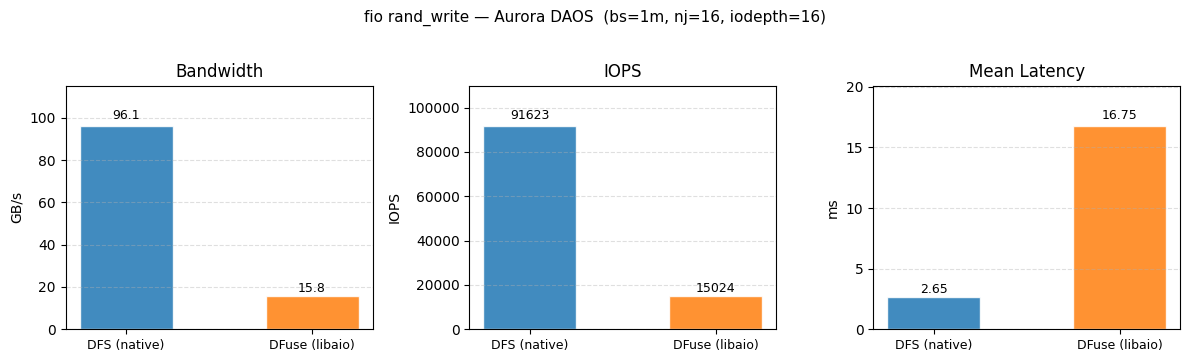

In [3]:
engines = [e for e in ENGINE_ORDER if e in df["engine"].values]
labels  = [ENGINE_LABELS[e] for e in engines]
x = np.arange(len(engines))
bar_w = 0.5

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))

metrics = [
    ("bw_GBs",      "GB/s",  "Bandwidth",   ".1f"),
    ("iops",        "IOPS",  "IOPS",        ".0f"),
    ("lat_mean_ms", "ms",    "Mean Latency", ".2f"),
]

for ax, (col, ylabel, title, fmt) in zip(axes, metrics):
    vals = [df[df.engine == e][col].values[0] for e in engines]
    bars = ax.bar(x, vals, bar_w,
                  color=[COLORS[e] for e in engines], alpha=0.85, edgecolor="white")
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.02,
                format(v, fmt), ha="center", va="bottom", fontsize=9)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=9)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    ax.set_ylim(0, max(vals) * 1.2)

plt.suptitle("fio rand_write — Aurora DAOS  (bs=1m, nj=16, iodepth=16)", y=1.02, fontsize=11)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "fio_3engines_rw_bw_iops_lat.pdf", dpi=150, bbox_inches="tight")
plt.show()

## Completion Latency Percentiles (clat)

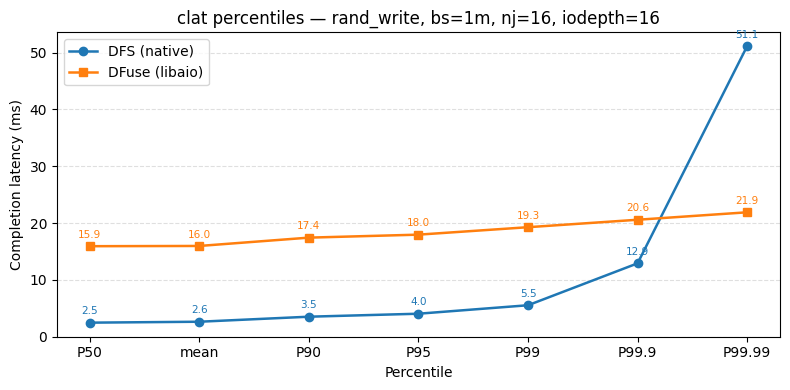

In [4]:
pct_cols   = ["clat_p50_ms", "clat_mean_ms", "clat_p90_ms",
              "clat_p95_ms", "clat_p99_ms",  "clat_p999_ms", "clat_p9999_ms"]
pct_labels = ["P50", "mean", "P90", "P95", "P99", "P99.9", "P99.99"]
markers    = {"dfs": "o", "dfuse": "s", "libil": "^"}   

fig, ax = plt.subplots(figsize=(8, 4))

for engine in engines:
    row  = df[df.engine == engine].iloc[0]
    vals = [row[c] for c in pct_cols]
    ax.plot(pct_labels, vals,
            marker=markers.get(engine, "o"),
            label=ENGINE_LABELS[engine],
            color=COLORS[engine],
            linewidth=1.8, markersize=6)
    for xi, v in enumerate(vals):
        ax.annotate(f"{v:.1f}", (xi, v),
                    textcoords="offset points", xytext=(0, 6),
                    ha="center", fontsize=7.5, color=COLORS[engine])

ax.set_xlabel("Percentile")
ax.set_ylabel("Completion latency (ms)")
ax.set_title("clat percentiles — rand_write, bs=1m, nj=16, iodepth=16")
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.set_ylim(bottom=0)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "fio_3engines_rw_clat_pct.pdf", dpi=150, bbox_inches="tight")
plt.show()

## Submission Latency and CPU Usage

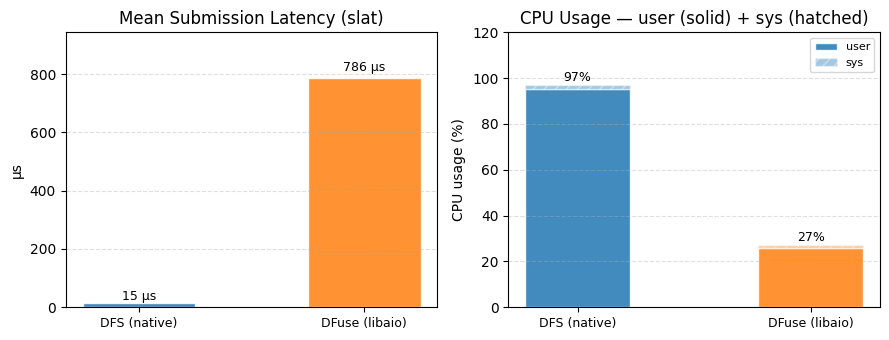

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))

# slat
ax = axes[0]
vals = [df[df.engine == e]["slat_mean_us"].values[0] for e in engines]
bars = ax.bar(x, vals, bar_w, color=[COLORS[e] for e in engines], alpha=0.85, edgecolor="white")
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.02,
            f"{v:.0f} µs", ha="center", va="bottom", fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel("µs")
ax.set_title("Mean Submission Latency (slat)")
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.set_ylim(0, max(vals) * 1.2)

# CPU
ax = axes[1]
bar_w2 = 0.35
usr_vals = [df[df.engine == e]["usr_cpu"].values[0] for e in engines]
sys_vals = [df[df.engine == e]["sys_cpu"].values[0] for e in engines]
ax.bar(x, usr_vals, bar_w2 + 0.1, label="user",
       color=[COLORS[e] for e in engines], alpha=0.85, edgecolor="white")
ax.bar(x, sys_vals, bar_w2 + 0.1, bottom=usr_vals,
       color=[COLORS[e] for e in engines], alpha=0.4, hatch="///",
       edgecolor="white", label="sys")
for i, (u, s) in enumerate(zip(usr_vals, sys_vals)):
    ax.text(i, u + s + 0.5, f"{u+s:.0f}%", ha="center", va="bottom", fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel("CPU usage (%)")
ax.set_title("CPU Usage — user (solid) + sys (hatched)")
ax.legend(fontsize=8)
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.set_ylim(0, 120)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "fio_3engines_rw_slat_cpu.pdf", dpi=150, bbox_inches="tight")
plt.show()

## Key Findings

**Setup:** fio random write, bs=1m, numjobs=16, iodepth=16, runtime=60 s, group\_reporting.  
Aurora DAOS pool `e2sar`. Results collected 2026-06-17.

---

### 1. DFS is 6× faster than DFuse (libaio) in throughput
| Engine | BW | IOPS | Mean lat |
|--------|------|------|----------|
| DFS (native)   | **96.1 GB/s** | **91,623** | **2.65 ms** |
| DFuse (libaio) |  15.8 GB/s   |  15,024    | 16.75 ms   |

The DAOS native `dfs` ioengine bypasses the kernel FUSE path entirely, communicating with DAOS servers over RDMA directly from userspace. With 16 jobs × iodepth 16 = 256 in-flight IOs, the native path saturates the fabric far more effectively.

### 2. DFuse slat overhead is the primary throughput cap
Mean **submission latency**: DFS = 14.7 µs, DFuse = **785.8 µs** (53×).  
The FUSE kernel–userspace round-trip adds ~770 µs per IO dispatch, capping DFuse IOPS at ~15 K regardless of iodepth. This is structural FUSE overhead, not a DAOS network issue.

### 3. DFuse tail latency is tighter; DFS has occasional outliers
Despite its far lower mean, DFS p99.99 = **51.1 ms** vs only **21.9 ms** for DFuse.  
DFuse's clat distribution is narrow (p50 = 15.9 ms, spread to p99.99 = 6 ms), while DFS is wider (p50 = 2.5 ms, spread to p99.99 = 49 ms). Occasional DFS outliers likely reflect DAOS client retransmission or RDMA jitter under 256-IO concurrency.

### 4. DFS trades CPU for throughput
| Engine | usr+sys CPU | Throughput |
|--------|------------|------------|
| DFS    | ~97% (95.4 + 1.7) | 96.1 GB/s |
| DFuse  | ~27% (25.9 + 1.3)  | 15.8 GB/s |

DFS delivers ~6× more bandwidth at ~3.6× higher CPU cost per node. The RDMA userspace path bypasses the kernel but requires active polling.

### 5. `libioil` is slower than plain DFuse — intercept mismatch with libaio
**Observed:** `libioil` bandwidth falls *below* plain DFuse despite the goal of bypassing FUSE overhead.

The root cause is an **engine/intercept mismatch**: fio's `libaio` engine submits I/O via kernel AIO syscalls (`io_submit` / `io_getevents`), not POSIX `write()` / `pwrite()`. `libioil` only intercepts POSIX blocking calls — it has no hook into the kernel AIO path. As a result:

- The actual data I/O still flows through FUSE unchanged (libioil never intercepts it)
- libioil's initialization, file-descriptor tracking, and per-call interception bookkeeping add overhead on top of the dfuse baseline
- Net effect: worse than plain dfuse

> The preferred intercept library `libpil4dfs` covers more I/O paths but **hangs with fio** (noted in the run script), so `libioil` was used as a fallback — it is simply not compatible with fio's `libaio` engine.

**To actually benefit from POSIX intercept with fio**, the `sync` or `psync` ioengine would be needed (which uses `write()`/`pwrite()`), but those engines do not support `iodepth > 1`, making them unsuitable for this concurrency test. For application code that uses POSIX I/O natively, `libioil` can still offer meaningful acceleration over plain DFuse.